# Full Pipeline: Summary Model → Negative Generation → SFT → DPO → Inference

### Pipeline Overview
```
Step 1 │ Fine-tune Summary Model on CSV Link 1  (SFT for summarisation)
Step 1.5│ Quality-check Summary Model on Link 1 hold-out (ROUGE + BERTScore + samples)
Step 2 │ Run Summary Model on CSV Link 2        (generate negative / bad summaries)
Step 3 │ Build DPO dataset from Link 2          (chosen = reference, rejected = model output)
Step 4 │ Split Link 2                           (SFT train / DPO train / Test)
Step 5 │ SFT fine-tune on Link 2 split
Step 6 │ DPO fine-tune on top of SFT model
Step 7 │ Inference & Evaluation (Base vs SFT vs SFT+DPO)
```

## 1. Installation & Setup

In [ ]:
!pip install -U PEFT

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install rouge-score bert-score

In [ ]:
print("✅ All packages installed successfully!")

## 2. Global Configuration

> **Replace the placeholder paths below with your actual CSV links / file paths.**

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION  –  edit these paths before running
# ─────────────────────────────────────────────────────────────────────────────

# CSV Link 1: used to fine-tune the initial Summary Model
# Expected columns: 'article' (or 'document') and 'summary'
CSV_LINK_1 = "/kaggle/input/datasets/abhisheksaha123456/samsum-dataset/samsum_summary.jsonl"   # <── replace

# CSV Link 2: used for negative-summary generation → then SFT/DPO/Inference
# Expected columns: 'article' (or 'document') and 'summary'
CSV_LINK_2 = "/kaggle/input/datasets/abhisheksaha123456/samsum-spotlight/samsum_spotlight.jsonl"   # <── replace

# ─────────────────────────────────────────────────────────────────────────────
# Model & training hyper-parameters
# ─────────────────────────────────────────────────────────────────────────────
BASE_MODEL_NAME   = "unsloth/llama-3-8b-bnb-4bit"
max_seq_length    = 1024
load_in_4bit      = True

# Number of rows from Link 2 to use for negative-summary generation (DPO rejected)
NEG_SUMMARY_SIZE  = 5000

# Train / DPO / Test split ratios for Link 2
SFT_RATIO   = 0.70
DPO_RATIO   = 0.25
TEST_RATIO  = 0.05

# Max summary length filter (characters)
MAX_SUMMARY_CHARS = 1024

print("✅ Configuration loaded.")
print(f"   CSV Link 1 : {CSV_LINK_1}")
print(f"   CSV Link 2 : {CSV_LINK_2}")
print(f"   Neg sample size for DPO rejected : {NEG_SUMMARY_SIZE:,}")

✅ Configuration loaded.
   CSV Link 1 : /kaggle/input/datasets/abhisheksaha123456/samsum-dataset/samsum_summary.jsonl
   CSV Link 2 : /kaggle/input/datasets/abhisheksaha123456/samsum-spotlight/samsum_spotlight.jsonl
   Neg sample size for DPO rejected : 5,000


In [6]:
import pandas as pd
df = pd.read_json("/kaggle/input/datasets/abhisheksaha123456/samsum-dataset/samsum_summary.jsonl", lines=True)

In [7]:
df.shape

(4222, 2)

In [8]:
df.head()

,text,summary
0,Amanda: I baked cookies. Do you want some? Jer...,Amanda baked cookies and will bring Jerry some...
1,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
2,Anna: where are you Omenah: at home Anna: I wi...,"Omenah is at home, Anna will be there in a min..."
3,Jonas: I’m running 10 minutes late. Could you ...,Jonas will be 10 minutes late. Natalie will le...
4,Elisa: Who wants to come for drinks tonight at...,"Elisa, Sadie, Carol, Liam, Tom and John want t..."


Dataset shape: (4222, 7)

First few rows:
                                                text  \
0  Amanda: I baked cookies. Do you want some? Jer...   
1  Edward: Rachel, I think I'm in ove with Bella....   
2  Anna: where are you Omenah: at home Anna: I wi...   
3  Jonas: I’m running 10 minutes late. Could you ...   
4  Elisa: Who wants to come for drinks tonight at...   

                                             summary  text_length  \
0  Amanda baked cookies and will bring Jerry some...           91   
1  Edward thinks he is in love with Bella. Rachel...          152   
2  Omenah is at home, Anna will be there in a min...           69   
3  Jonas will be 10 minutes late. Natalie will le...          230   
4  Elisa, Sadie, Carol, Liam, Tom and John want t...          563   

   summary_length  text_tokens  summary_tokens  total_tokens  
0              56           22              14            36  
1              96           38              24            62  
2              50

/tmp/ipykernel_367/1410072341.py:167: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot([df['text_tokens'], df['summary_tokens']],



✓ Visualization saved to 'length_analysis_visualization.png'


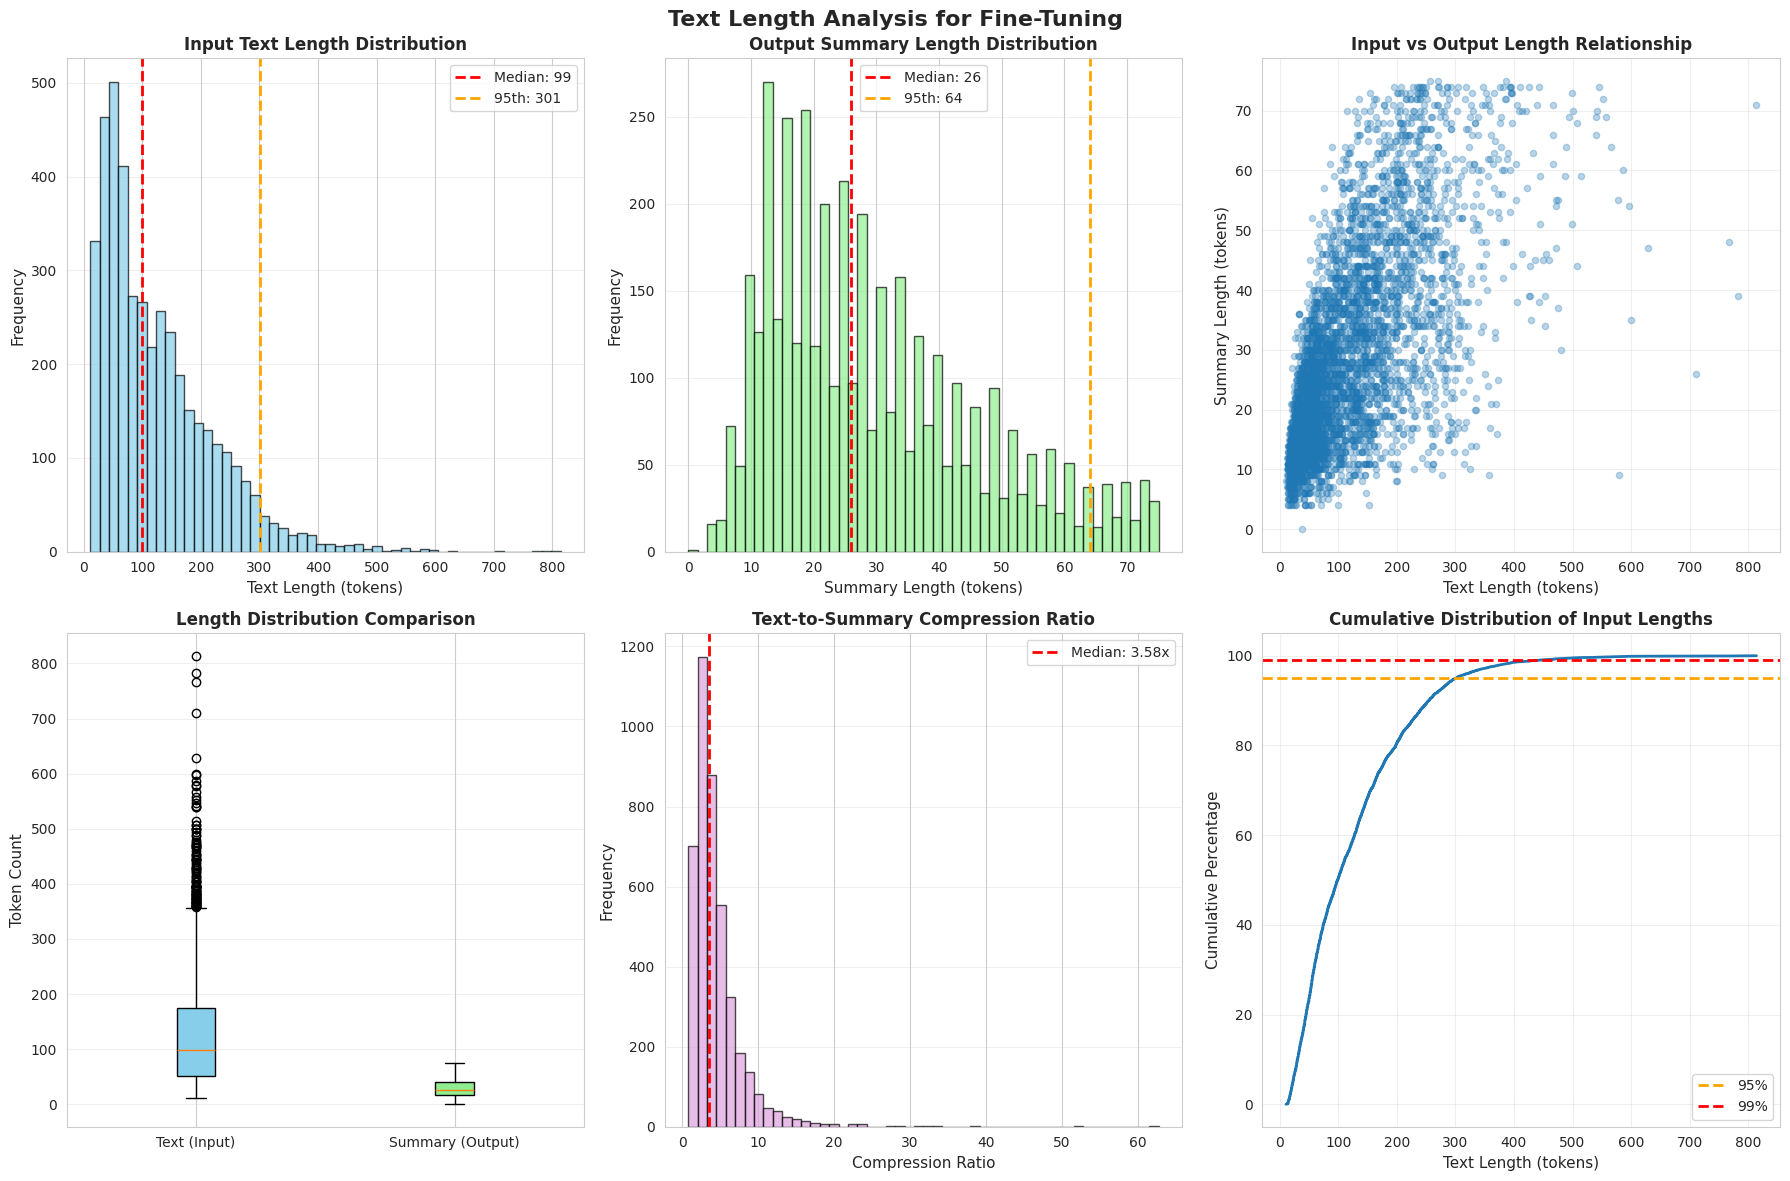

✓ Truncation coverage plot saved to 'truncation_coverage.png'


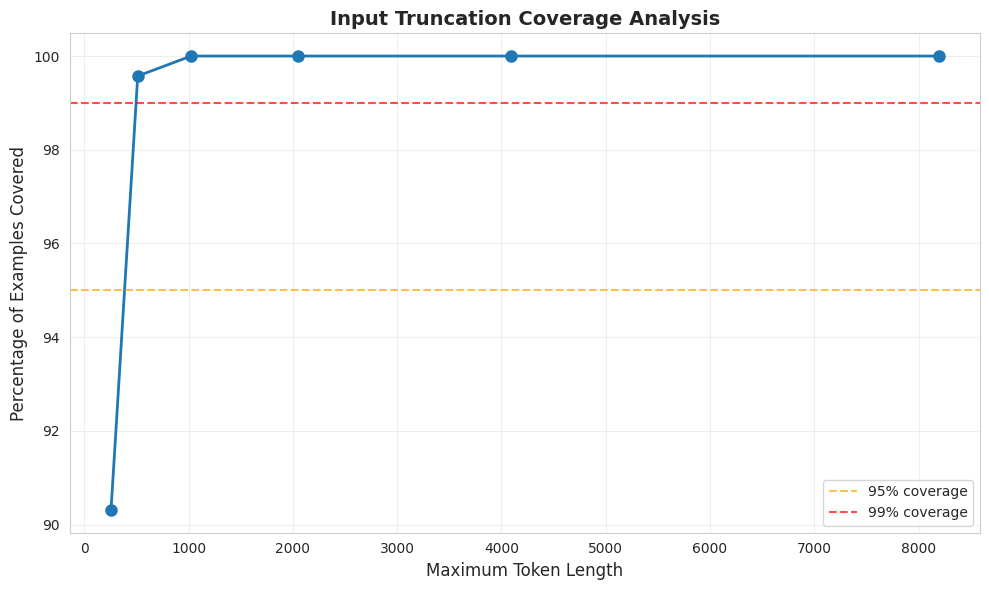



📊 SUMMARY STATISTICS TABLE:
                    Metric      Value
        Input: Mean tokens 125.064661
      Input: Median tokens  99.000000
    Input: 95th percentile 301.000000
    Input: 99th percentile 443.000000
         Input: Max tokens 814.000000
       Output: Mean tokens  29.568925
     Output: Median tokens  26.000000
   Output: 95th percentile  64.000000
   Output: 99th percentile  73.000000
        Output: Max tokens  75.000000
   Compression Ratio: Mean   4.456100
 Compression Ratio: Median   3.581743
    Recommended max_tokens  83.000000
Recommended context window 443.000000

✓ Statistics saved to 'length_statistics.csv'


FINAL RECOMMENDATIONS FOR FINE-TUNING

1. 🎯 max_tokens parameter: 83
   - This covers 95% of your summaries with a 30% safety buffer
   - Alternative (99th): 87

2. 📏 Context window requirement: 443 tokens
   - This handles 99% of your input texts
   - Consider truncating longer inputs or using a model with sufficient context

3. ✂️  Input truncatio

In [10]:
# ============================================================================
# TEXT LENGTH ANALYSIS FOR FINE-TUNING
# Statistical analysis to determine optimal max_tokens and context window
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================================
# LOAD YOUR DATA
# ============================================================================

# REPLACE THIS with your actual data loading code

print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

# ============================================================================
# CALCULATE LENGTHS
# ============================================================================

# Calculate character lengths
df['text_length'] = df['text'].str.len()
df['summary_length'] = df['summary'].str.len()

# Estimate token counts (rough estimate: 1 token ≈ 4 characters)
df['text_tokens'] = (df['text_length'] / 4).astype(int)
df['summary_tokens'] = (df['summary_length'] / 4).astype(int)
df['total_tokens'] = df['text_tokens'] + df['summary_tokens']

print("\n✓ Length calculations complete")
print(df[['text_tokens', 'summary_tokens', 'total_tokens']].head())

# ============================================================================
# QUICK SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*70)
print("QUICK FINE-TUNING PARAMETER GUIDE")
print("="*70)

print(f"\n📊 Dataset size: {len(df):,} examples")

print(f"\n📝 INPUT (text) lengths in tokens:")
print(f"   Mean:   {df['text_tokens'].mean():.0f}")
print(f"   Median: {df['text_tokens'].median():.0f}")
print(f"   95th:   {df['text_tokens'].quantile(0.95):.0f}")
print(f"   99th:   {df['text_tokens'].quantile(0.99):.0f}")
print(f"   Max:    {df['text_tokens'].max():.0f}")

print(f"\n✍️  OUTPUT (summary) lengths in tokens:")
print(f"   Mean:   {df['summary_tokens'].mean():.0f}")
print(f"   Median: {df['summary_tokens'].median():.0f}")
print(f"   95th:   {df['summary_tokens'].quantile(0.95):.0f}")
print(f"   99th:   {df['summary_tokens'].quantile(0.99):.0f}")
print(f"   Max:    {df['summary_tokens'].max():.0f}")

print(f"\n🎯 RECOMMENDED PARAMETERS:")

# Max tokens recommendation
recommended_max = int(df['summary_tokens'].quantile(0.95) * 1.3)
print(f"\n   max_tokens: {recommended_max}")
print(f"   (Covers 95% of outputs with 30% buffer)")

# Context window recommendation
print(f"\n   Context window needed: {int(df['text_tokens'].quantile(0.99))}")
print(f"   (To handle 99% of inputs)")

print("\n" + "="*70)

# ============================================================================
# DETAILED STATISTICS
# ============================================================================

print("\n\nTEXT (INPUT) TOKEN STATISTICS")
print("="*50)
print(df['text_tokens'].describe())
print(f"\n5th percentile:  {df['text_tokens'].quantile(0.05):.0f}")
print(f"95th percentile: {df['text_tokens'].quantile(0.95):.0f}")
print(f"99th percentile: {df['text_tokens'].quantile(0.99):.0f}")

print("\n\nSUMMARY (OUTPUT) TOKEN STATISTICS")
print("="*50)
print(df['summary_tokens'].describe())
print(f"\n5th percentile:  {df['summary_tokens'].quantile(0.05):.0f}")
print(f"95th percentile: {df['summary_tokens'].quantile(0.95):.0f}")
print(f"99th percentile: {df['summary_tokens'].quantile(0.99):.0f}")

# ============================================================================
# TRUNCATION ANALYSIS
# ============================================================================

print("\n\nTRUNCATION ANALYSIS")
print("="*50)
print("If you truncate INPUT texts to:")

truncation_options = [256, 512, 1024, 2048, 4096, 8192]
truncation_data = []

for length in truncation_options:
    pct_covered = (df['text_tokens'] <= length).mean() * 100
    print(f"   {length:5d} tokens → {pct_covered:5.1f}% of examples fit")
    truncation_data.append({'max_length': length, 'coverage': pct_covered})

truncation_df = pd.DataFrame(truncation_data)

# ============================================================================
# COMPRESSION RATIO ANALYSIS
# ============================================================================

compression_ratio = df['text_length'] / df['summary_length']

print("\n\nCOMPRESSION RATIO (text length / summary length)")
print("="*50)
print(f"Mean:   {compression_ratio.mean():.2f}x")
print(f"Median: {compression_ratio.median():.2f}x")
print(f"Min:    {compression_ratio.min():.2f}x")
print(f"Max:    {compression_ratio.max():.2f}x")
print(f"\nThis means summaries are typically {compression_ratio.mean():.1f}x shorter than the original text")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Text Length Analysis for Fine-Tuning', fontsize=16, fontweight='bold')

# 1. Text length distribution
axes[0, 0].hist(df['text_tokens'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].axvline(df['text_tokens'].median(), color='red', linestyle='--', linewidth=2, 
                   label=f'Median: {df["text_tokens"].median():.0f}')
axes[0, 0].axvline(df['text_tokens'].quantile(0.95), color='orange', linestyle='--', linewidth=2, 
                   label=f'95th: {df["text_tokens"].quantile(0.95):.0f}')
axes[0, 0].set_xlabel('Text Length (tokens)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Input Text Length Distribution', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Summary length distribution
axes[0, 1].hist(df['summary_tokens'], bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 1].axvline(df['summary_tokens'].median(), color='red', linestyle='--', linewidth=2, 
                   label=f'Median: {df["summary_tokens"].median():.0f}')
axes[0, 1].axvline(df['summary_tokens'].quantile(0.95), color='orange', linestyle='--', linewidth=2, 
                   label=f'95th: {df["summary_tokens"].quantile(0.95):.0f}')
axes[0, 1].set_xlabel('Summary Length (tokens)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Output Summary Length Distribution', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Scatter plot - Input vs Output
axes[0, 2].scatter(df['text_tokens'], df['summary_tokens'], alpha=0.3, s=20)
axes[0, 2].set_xlabel('Text Length (tokens)', fontsize=11)
axes[0, 2].set_ylabel('Summary Length (tokens)', fontsize=11)
axes[0, 2].set_title('Input vs Output Length Relationship', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. Box plots comparison
bp = axes[1, 0].boxplot([df['text_tokens'], df['summary_tokens']], 
                         labels=['Text (Input)', 'Summary (Output)'],
                         patch_artist=True)
bp['boxes'][0].set_facecolor('skyblue')
bp['boxes'][1].set_facecolor('lightgreen')
axes[1, 0].set_ylabel('Token Count', fontsize=11)
axes[1, 0].set_title('Length Distribution Comparison', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Compression ratio distribution
axes[1, 1].hist(compression_ratio, bins=50, edgecolor='black', alpha=0.7, color='plum')
axes[1, 1].axvline(compression_ratio.median(), color='red', linestyle='--', linewidth=2, 
                   label=f'Median: {compression_ratio.median():.2f}x')
axes[1, 1].set_xlabel('Compression Ratio', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Text-to-Summary Compression Ratio', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Cumulative distribution
sorted_text = np.sort(df['text_tokens'])
cumulative = np.arange(1, len(sorted_text) + 1) / len(sorted_text) * 100
axes[1, 2].plot(sorted_text, cumulative, linewidth=2)
axes[1, 2].axhline(95, color='orange', linestyle='--', linewidth=2, label='95%')
axes[1, 2].axhline(99, color='red', linestyle='--', linewidth=2, label='99%')
axes[1, 2].set_xlabel('Text Length (tokens)', fontsize=11)
axes[1, 2].set_ylabel('Cumulative Percentage', fontsize=11)
axes[1, 2].set_title('Cumulative Distribution of Input Lengths', fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('length_analysis_visualization.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved to 'length_analysis_visualization.png'")
plt.show()

# ============================================================================
# TRUNCATION COVERAGE VISUALIZATION
# ============================================================================

plt.figure(figsize=(10, 6))
plt.plot(truncation_df['max_length'], truncation_df['coverage'], marker='o', linewidth=2, markersize=8)
plt.axhline(y=95, color='orange', linestyle='--', label='95% coverage', alpha=0.7)
plt.axhline(y=99, color='red', linestyle='--', label='99% coverage', alpha=0.7)
plt.xlabel('Maximum Token Length', fontsize=12)
plt.ylabel('Percentage of Examples Covered', fontsize=12)
plt.title('Input Truncation Coverage Analysis', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('truncation_coverage.png', dpi=300, bbox_inches='tight')
print("✓ Truncation coverage plot saved to 'truncation_coverage.png'")
plt.show()

# ============================================================================
# EXPORT SUMMARY STATISTICS
# ============================================================================

summary_stats = pd.DataFrame({
    'Metric': [
        'Input: Mean tokens',
        'Input: Median tokens',
        'Input: 95th percentile',
        'Input: 99th percentile',
        'Input: Max tokens',
        'Output: Mean tokens',
        'Output: Median tokens',
        'Output: 95th percentile',
        'Output: 99th percentile',
        'Output: Max tokens',
        'Compression Ratio: Mean',
        'Compression Ratio: Median',
        'Recommended max_tokens',
        'Recommended context window'
    ],
    'Value': [
        df['text_tokens'].mean(),
        df['text_tokens'].median(),
        df['text_tokens'].quantile(0.95),
        df['text_tokens'].quantile(0.99),
        df['text_tokens'].max(),
        df['summary_tokens'].mean(),
        df['summary_tokens'].median(),
        df['summary_tokens'].quantile(0.95),
        df['summary_tokens'].quantile(0.99),
        df['summary_tokens'].max(),
        compression_ratio.mean(),
        compression_ratio.median(),
        int(df['summary_tokens'].quantile(0.95) * 1.3),
        int(df['text_tokens'].quantile(0.99))
    ]
})

print("\n\n📊 SUMMARY STATISTICS TABLE:")
print("="*50)
print(summary_stats.to_string(index=False))

summary_stats.to_csv('length_statistics.csv', index=False)
print("\n✓ Statistics saved to 'length_statistics.csv'")

# ============================================================================
# FINAL RECOMMENDATIONS
# ============================================================================

print("\n\n" + "="*70)
print("FINAL RECOMMENDATIONS FOR FINE-TUNING")
print("="*70)

recommended_max = int(df['summary_tokens'].quantile(0.95) * 1.3)
context_99 = int(df['text_tokens'].quantile(0.99))

print(f"\n1. 🎯 max_tokens parameter: {recommended_max}")
print(f"   - This covers 95% of your summaries with a 30% safety buffer")
print(f"   - Alternative (99th): {int(df['summary_tokens'].quantile(0.99) * 1.2)}")

print(f"\n2. 📏 Context window requirement: {context_99} tokens")
print(f"   - This handles 99% of your input texts")
print(f"   - Consider truncating longer inputs or using a model with sufficient context")

print(f"\n3. ✂️  Input truncation strategy:")
for length in [512, 1024, 2048, 4096]:
    pct = (df['text_tokens'] <= length).mean() * 100
    if pct >= 95:
        print(f"   → Truncate at {length} tokens (covers {pct:.1f}%)")
        break
else:
    print(f"   → Consider {context_99} tokens or higher")

print(f"\n4. 📊 Dataset info:")
print(f"   - Total examples: {len(df):,}")
print(f"   - Avg tokens per example: {df['total_tokens'].mean():.0f}")
print(f"   - Compression ratio: {compression_ratio.mean():.1f}x")

print(f"\n5. 💡 Tips:")
print(f"   - Monitor validation loss to avoid overfitting")
print(f"   - Consider splitting very long inputs if they exceed model limits")
print(f"   - Use early stopping based on validation performance")

print("\n" + "="*70)
print("\n✓ Analysis complete!")

## 3. Load Base Model

In [11]:
from unsloth import FastLanguageModel
import torch

base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name    = BASE_MODEL_NAME,
    max_seq_length = max_seq_length,
    dtype          = torch.bfloat16,
    load_in_4bit   = load_in_4bit,
)

if base_tokenizer.chat_template is None:
    base_tokenizer.chat_template = (
        "{% set loop_messages = messages %}"
        "{% for message in loop_messages %}"
        "{% set content = '<|start_header_id|>' + message['role'] + '<|end_header_id|>\\n\\n'"
        "+ message['content'] | trim + '<|eot_id|>' %}"
        "{% if loop.index0 == 0 %}{% set content = bos_token + content %}{% endif %}"
        "{{ content }}{% endfor %}"
        "{% if add_generation_prompt %}{{ '<|start_header_id|>assistant<|end_header_id|>\\n\\n' }}{% endif %}"
    )

print("✅ Base model loaded!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-02-19 07:32:59.528763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771486379.704004     367 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771486379.757699     367 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771486380.197945     367 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771486380.197968     367 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771486380.197970     367 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 9.0. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/198 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

✅ Base model loaded!


---
# PHASE 1 — Fine-tune Summary Model on CSV Link 1

In [12]:
df.iloc[1]["text"]

"Edward: Rachel, I think I'm in ove with Bella.. rachel: Dont say anything else.. Edward: What do you mean?? rachel: Open your fu**ing door.. I'm outside"

In [13]:
df.iloc[1]["summary"]

'Edward thinks he is in love with Bella. Rachel wants Edward to open his door. Rachel is outside.'

## 4. Load & Prepare CSV Link 1

In [14]:
import pandas as pd

df_link1_raw = pd.read_json(CSV_LINK_1,lines=True)

# Normalise column names: accept 'document'/'text' as alias for 'article'
if 'article' not in df_link1_raw.columns:
    for alias in ['document', 'text', 'input']:
        if alias in df_link1_raw.columns:
            df_link1_raw = df_link1_raw.rename(columns={alias: 'article'})
            break

print(f"Link 1 raw size   : {len(df_link1_raw):,}")
print(f"Columns           : {list(df_link1_raw.columns)}")

# Filter by summary length
df_link1_raw = df_link1_raw[df_link1_raw['summary'].str.len() <= MAX_SUMMARY_CHARS].reset_index(drop=True)
print(f"After length filter: {len(df_link1_raw):,}")

# ── Hold out 10% for Summary Model quality test ──────────────────────────────
df_link1_raw = df_link1_raw.sample(frac=1, random_state=42).reset_index(drop=True)
n_link1_test  = max(50, int(len(df_link1_raw) * 0.10))   # at least 50 samples
df_link1_test = df_link1_raw.iloc[:n_link1_test].reset_index(drop=True)
df_link1      = df_link1_raw.iloc[n_link1_test:].reset_index(drop=True)

print(f"Link 1 train split : {len(df_link1):,}")
print(f"Link 1 test  split : {len(df_link1_test):,}  (held out for Summary Model evaluation)")
df_link1.head(3)

Link 1 raw size   : 4,222
Columns           : ['article', 'summary']
After length filter: 4,222
Link 1 train split : 3,800
Link 1 test  split : 422  (held out for Summary Model evaluation)


,article,summary
0,Kate: did you buy the gift for Maddy? Sheila: ...,Shannon ordered toys for the kids. Sheila coul...
1,"Amelie: Hi Robin, I have some bad news Robin: ...",Amelie won't come to Robin's birthday party be...
2,"Ingmar: Hi Judy, do you think you might have t...",Igmar is applying for a customer service job t...


In [15]:
from datasets import Dataset

# ============================================================================
# UPDATED SYSTEM PROMPT
# ============================================================================

SUMMARY_SYSTEM_PROMPT = (
    "You are a professional dialogue summarizer. "
    "Your task is to generate concise, accurate summaries of conversations. "
    "Focus on the key actions, decisions, and outcomes. "
    "Avoid informal phrasing. "
    "Write in one clear sentence unless more detail is necessary."
)

# ============================================================================
# FORMAT FOR SFT
# ============================================================================

def prepare_sft_format(examples):
    """Format data for supervised fine-tuning (Summary writing)"""
    
    messages_list = []
    
    for text, summary in zip(examples["article"], examples["summary"]):
        
        user_prompt = (
            "Summarize the following conversation concisely.\n\n"
            "Requirements:\n"
            "- Capture the main idea\n"
            "- Focus on actions and outcomes\n"
            "- Avoid unnecessary details\n\n"
            f"Conversation:\n{text[:2048]}"
        )
        
        messages = [
            {"role": "system", "content": SUMMARY_SYSTEM_PROMPT},
            {"role": "user", "content": user_prompt},
            {"role": "assistant", "content": summary.strip()},
        ]
        
        messages_list.append(messages)
        
    return {"messages": messages_list}


def apply_sft_chat_template(example, tokenizer):
    """Apply chat template to messages"""
    
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    
    return {"text": text}


# ============================================================================
# CREATE HF DATASET
# ============================================================================

link1_hf = Dataset.from_pandas(df_link1[["article", "summary"]])

link1_hf = link1_hf.map(
    prepare_sft_format,
    batched=True,
    remove_columns=["article", "summary"],
    desc="Formatting Link 1 SFT data",
)

print(f"\n✅ SFT dataset prepared: {len(link1_hf)} samples")
print("\nSample messages:")
print(link1_hf[0]["messages"])

link1_hf = link1_hf.map(
    lambda x: apply_sft_chat_template(x, base_tokenizer),
    remove_columns=["messages"],
    desc="Applying chat template",
)

print("\n✅ Chat template applied")
print("\nSample formatted text:")
print(link1_hf[0]["text"][:5000] + "...")


Formatting Link 1 SFT data:   0%|          | 0/3800 [00:00<?, ? examples/s]


✅ SFT dataset prepared: 3800 samples

Sample messages:
[{'content': 'You are a professional dialogue summarizer. Your task is to generate concise, accurate summaries of conversations. Focus on the key actions, decisions, and outcomes. Avoid informal phrasing. Write in one clear sentence unless more detail is necessary.', 'role': 'system'}, {'content': "Summarize the following conversation concisely.\n\nRequirements:\n- Capture the main idea\n- Focus on actions and outcomes\n- Avoid unnecessary details\n\nConversation:\nKate: did you buy the gift for Maddy? Sheila: no, I'm sorry but I couldn't do that before the weekend Kate: ok Kate: and what about those toys for the kids? Sheila: Shannon ordered it last week but she won't get it before wednesday Kate: ok so we still have time Sheila: I don't know if I make it this week, I'm sick (yes, again...) and don't know when I get better Kate: again??? so sorry to hear that! Kate: get better soon! Sheila: thanks. look here's a picture of option

Applying chat template:   0%|          | 0/3800 [00:00<?, ? examples/s]


✅ Chat template applied

Sample formatted text:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a professional dialogue summarizer. Your task is to generate concise, accurate summaries of conversations. Focus on the key actions, decisions, and outcomes. Avoid informal phrasing. Write in one clear sentence unless more detail is necessary.<|eot_id|><|start_header_id|>user<|end_header_id|>

Summarize the following conversation concisely.

Requirements:
- Capture the main idea
- Focus on actions and outcomes
- Avoid unnecessary details

Conversation:
Kate: did you buy the gift for Maddy? Sheila: no, I'm sorry but I couldn't do that before the weekend Kate: ok Kate: and what about those toys for the kids? Sheila: Shannon ordered it last week but she won't get it before wednesday Kate: ok so we still have time Sheila: I don't know if I make it this week, I'm sick (yes, again...) and don't know when I get better Kate: again??? so sorry to hear that! Kate: get better soon

## 5. SFT — Train Summary Model on Link 1

In [ ]:
# summary_model = FastLanguageModel.get_peft_model(
#     base_model,
#     r                    = 16,
#     target_modules       = ["q_proj", "k_proj", "v_proj", "o_proj",
#                             "gate_proj", "up_proj", "down_proj"],
#     lora_alpha           = 32,
#     lora_dropout         = 0,
#     bias                 = "none",
#     use_gradient_checkpointing = "unsloth",
#     random_state         = 42,
#     use_rslora           = False,
#     loftq_config         = None,
# )
# print("✅ Summary model (LoRA) ready.")

In [ ]:
# from trl import SFTTrainer
# from transformers import TrainingArguments
# from unsloth import is_bfloat16_supported

# summary_trainer = SFTTrainer(
#     model         = summary_model,
#     tokenizer     = base_tokenizer,
#     train_dataset = link1_hf,
#     dataset_text_field = "text",
#     max_seq_length = max_seq_length,
#     dataset_num_proc = 2,
#     packing       = False,
#     TORCHDYNAMO_VERBOSE=1,
#     args          = TrainingArguments(
#         per_device_train_batch_size   = 2,
#         gradient_accumulation_steps  = 2,
#         warmup_steps                 = 5,
#         num_train_epochs             = 2,
#         learning_rate                = 2e-4,
#         fp16                         = not is_bfloat16_supported(),
#         bf16                         = is_bfloat16_supported(),
#         logging_steps                = 10,
#         optim                        = "adamw_8bit",
#         weight_decay                 = 0.01,
#         lr_scheduler_type            = "linear",
#         seed                         = 42,
#         output_dir                   = "outputs_summary_model",
#         report_to                    = "none",
#         # NEW: HIGHLY RECOMMENDED
#         save_strategy="steps",
#         save_steps=100,
#     ),
# )

# print("🚀 Training Summary Model on Link 1 ...")
# summary_stats = summary_trainer.train()
# print(f"✅ Summary Model trained | runtime: {summary_stats.metrics['train_runtime']/60:.2f} min")

In [ ]:
# summary_model.save_pretrained("summary_model_link1")
# base_tokenizer.save_pretrained("summary_model_link1")
# print("✅ Summary model saved to 'summary_model_link1'")

---
# PHASE 1.5 — Summary Model Quality Check (Link 1 Hold-out Test)

Before moving on to Phase 2, we run a quick inference pass on the **10% hold-out split from Link 1** to verify the Summary Model has learned to summarise well.

We compare it against the **base model** and report ROUGE + BERTScore + 5 printed sample comparisons.

## 6. Summary Model — Inference on Link 1 Hold-out

In [ ]:
NUM_LINK1_TEST_SAMPLES = min(10, len(df_link1_test))
link1_test_articles = df_link1_test['article'].tolist()[:NUM_LINK1_TEST_SAMPLES]
link1_test_refs     = df_link1_test['summary'].tolist()[:NUM_LINK1_TEST_SAMPLES]

print(f"Running Summary Model quality check on {NUM_LINK1_TEST_SAMPLES} Link 1 hold-out samples ...")

def _gen_summary_check(model, tokenizer, article, max_new_tokens=100):
    user_prompt = (
        "Summarise the following conversation concisely.\n\n"
        "Requirements:\n"
        "- Capture the main idea\n"
        "- Focus on actions and outcomes\n"
        "- Avoid unnecessary details\n\n"
        f"Conversation:\n{article}"
    )
    messages = [
        {"role": "system", "content": SUMMARY_SYSTEM_PROMPT},
        {"role": "user",   "content": user_prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")

    model.eval()
    with torch.no_grad():
        out = model.generate(
            input_ids      = inputs,
            max_new_tokens = max_new_tokens,
            temperature    = 0.3,
            do_sample      = True,
            use_cache      = True,
            eos_token_id   = tokenizer.eos_token_id,   # ← stop at EOS
            pad_token_id   = tokenizer.eos_token_id,   # ← fix pad warning
        )

    decoded = tokenizer.decode(
        out[0][inputs.shape[1]:],
        skip_special_tokens=True
    ).strip()

    # Safety: cut anything after 'assistant' if template leaks through
    if "assistant" in decoded:
        decoded = decoded.split("assistant")[0].strip()

    return decoded

# ── Base model predictions ─────────────────────────────────────────
FastLanguageModel.for_inference(base_model)
print("\n🤖 Base model generating summaries ...")
link1_base_preds = [
    _gen_summary_check(base_model, base_tokenizer, a)
    for a in link1_test_articles
]
print(f"   Done ({len(link1_base_preds)} predictions)")

# ── Fine-tuned summary model predictions ──────────────────────────
FastLanguageModel.for_inference(summary_model)
print("\n📝 Summary Model generating summaries ...")
link1_summary_preds = [
    _gen_summary_check(summary_model, base_tokenizer, a)
    for a in link1_test_articles
]
print(f"   Done ({len(link1_summary_preds)} predictions)")

## 7. Summary Model — ROUGE Evaluation

In [ ]:
from rouge_score import rouge_scorer as _rouge_mod

_chk_scorer = _rouge_mod.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def _calc_rouge_chk(preds, refs):
    r1, r2, rl = [], [], []
    for p, r in zip(preds, refs):
        s = _chk_scorer.score(r, p)
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s['rougeL'].fmeasure)
    return {'rouge1': sum(r1)/len(r1), 'rouge2': sum(r2)/len(r2), 'rougeL': sum(rl)/len(rl)}

link1_base_rouge    = _calc_rouge_chk(link1_base_preds,    link1_test_refs)
link1_summary_rouge = _calc_rouge_chk(link1_summary_preds, link1_test_refs)

print("\n" + "="*70)
print("SUMMARY MODEL QUALITY CHECK \u2014 ROUGE (Link 1 Hold-out)")
print("="*70)
print(f"{'Metric':<12} {'Base Model':<16} {'Summary Model':<16} {'Delta':<12}")
print("-" * 70)
for m in ['rouge1', 'rouge2', 'rougeL']:
    bv = link1_base_rouge[m]
    sv = link1_summary_rouge[m]
    d  = sv - bv
    arrow = "\u25b2" if d >= 0 else "\u25bc"
    print(f"{m:<12} {bv:<16.4f} {sv:<16.4f} {arrow} {abs(d):.4f}")
print("="*70)

## 8. Summary Model — BERTScore Evaluation

In [ ]:
from bert_score import score as _bert_score_chk

print("Calculating BERTScore for Base model (Link 1 hold-out) ...")
P_b, R_b, F1_b = _bert_score_chk(
    link1_base_preds, link1_test_refs,
    lang="en", verbose=False,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

print("Calculating BERTScore for Summary Model (Link 1 hold-out) ...")
P_s, R_s, F1_s = _bert_score_chk(
    link1_summary_preds, link1_test_refs,
    lang="en", verbose=False,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

link1_base_bs    = {'precision': P_b.mean().item(), 'recall': R_b.mean().item(), 'f1': F1_b.mean().item()}
link1_summary_bs = {'precision': P_s.mean().item(), 'recall': R_s.mean().item(), 'f1': F1_s.mean().item()}

print("\n" + "="*70)
print("SUMMARY MODEL QUALITY CHECK \u2014 BERTSCORE (Link 1 Hold-out)")
print("="*70)
print(f"{'Metric':<15} {'Base Model':<16} {'Summary Model':<16} {'Delta':<12}")
print("-" * 70)
for metric in ['precision', 'recall', 'f1']:
    bv = link1_base_bs[metric]
    sv = link1_summary_bs[metric]
    d  = sv - bv
    arrow = "\u25b2" if d >= 0 else "\u25bc"
    print(f"{metric:<15} {bv:<16.4f} {sv:<16.4f} {arrow} {abs(d):.4f}")
print("="*70)

# Pass / Fail gate based on ROUGE-L
rouge_l_gain = link1_summary_rouge['rougeL'] - link1_base_rouge['rougeL']
if rouge_l_gain > 0:
    print(f"\n\u2705 PASSED \u2014 Summary Model ROUGE-L improved by +{rouge_l_gain:.4f} over base.")
else:
    print(f"\n\u26a0\ufe0f  WARNING \u2014 Summary Model did NOT beat base on ROUGE-L (\u0394 = {rouge_l_gain:.4f}).")
    print("   Consider: more epochs, lower LR, or a larger training subset from Link 1.")

## 9. Summary Model — Sample Output Comparison (5 examples)

In [ ]:
print("\n" + "="*100)
print("SUMMARY MODEL QUALITY CHECK \u2014 SAMPLE OUTPUTS (Link 1 Hold-out)")
print("="*100)

for i in range(5):
    print(f"\n{'\u2500'*100}")
    print(f"SAMPLE {i+1} / 5")
    print(f"{'\u2500'*100}")

    print(f"\n\U0001f4f0 ARTICLE (first 400 chars):")
    print(f"{link1_test_articles[i][:400]} ...")

    print(f"\n\U0001f4dd REFERENCE SUMMARY:")
    print(link1_test_refs[i])

    print(f"\n\U0001f916 BASE MODEL:")
    print(link1_base_preds[i])

    print(f"\n\U0001f3af SUMMARY MODEL (trained on Link 1):")
    print(link1_summary_preds[i])

print(f"\n{'='*100}")
print("\u2705 Phase 1.5 complete \u2014 Summary Model quality verified. Proceeding to Phase 2.")
print(f"{'='*100}")

---
# PHASE 2 — Generate Negative Summaries for CSV Link 2

## 10. Load CSV Link 2 & Generate Negative Summaries

In [22]:
# df_link2 = pd.read_csv(CSV_LINK_2)

df_link2 = pd.read_json(CSV_LINK_2, lines=True)
# Normalise column names
if 'article' not in df_link2.columns:
    for alias in ['document', 'text', 'input']:
        if alias in df_link2.columns:
            df_link2 = df_link2.rename(columns={alias: 'article'})
            break

print(f"Link 2 raw size   : {len(df_link2):,}")
print(f"Columns           : {list(df_link2.columns)}")

# Filter by summary length
df_link2 = df_link2[df_link2['summary'].str.len() <= MAX_SUMMARY_CHARS].reset_index(drop=True)
print(f"After length filter: {len(df_link2):,}")
df_link2.head(3)

Link 2 raw size   : 10,480
Columns           : ['article', 'summary']
After length filter: 10,480


,article,summary
0,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
1,"Tim: Hi, what's up? Kim: Bad mood tbh, I was g...",Kim may try the pomodoro technique recommended...
2,Sam: hey overheard rick say something Sam: i d...,"Sam is confused, because he overheard Rick com..."


In [23]:
NEG_SUMMARY_SIZE = 5000

In [ ]:
# # ─────────────────────────────────────────────────────────────────────────────
# # Generate negative (rejected) summaries using trained Summary Model
# # ─────────────────────────────────────────────────────────────────────────────
# from tqdm import tqdm

# FastLanguageModel.for_inference(summary_model)
# summary_model.eval()

# df_neg = df_link2.iloc[:NEG_SUMMARY_SIZE].copy().reset_index(drop=True)
# neg_summaries = []

# print(f"🔄 Generating negative summaries for {NEG_SUMMARY_SIZE:,} examples from Link 2 ...")

# for i, row in tqdm(df_neg.iterrows(), total=NEG_SUMMARY_SIZE, desc="Generating negatives"):
#     user_prompt = (
#         "Summarise the following article concisely.\n\n"
#         "Requirements:\n"
#         "- Capture the main idea\n"
#         "- Focus on key facts\n"
#         "- Avoid unnecessary details\n\n"
#         f"Article:\n{row['article']}"
#     )
#     messages = [
#         {"role": "system", "content": SUMMARY_SYSTEM_PROMPT},
#         {"role": "user",   "content": user_prompt},
#     ]
#     inputs = base_tokenizer.apply_chat_template(
#         messages,
#         tokenize=True,
#         add_generation_prompt=True,
#         return_tensors="pt"
#     ).to("cuda")

#     with torch.no_grad():
#         outputs = summary_model.generate(
#             input_ids      = inputs,
#             max_new_tokens = 100,
#             temperature    = 0.8,                          # high for diverse "rejected"
#             do_sample      = True,
#             use_cache      = True,
#             eos_token_id   = base_tokenizer.eos_token_id,
#             pad_token_id   = base_tokenizer.eos_token_id,
#         )

#     generated = base_tokenizer.decode(
#         outputs[0][inputs.shape[1]:],
#         skip_special_tokens=True
#     ).strip()

#     # Safety: cut if chat template leaks through
#     if "assistant" in generated:
#         generated = generated.split("assistant")[0].strip()

#     neg_summaries.append(generated)

# df_neg["rejected_summary"] = neg_summaries
# df_neg.to_csv("link2_with_negatives.csv", index=False)
# print("✅ Negative summaries generated and saved to 'link2_with_negatives.csv'")
# print(df_neg[["article", "summary", "rejected_summary"]].head(2))

In [ ]:
# from huggingface_hub import login
# from datasets import Dataset
# import pandas as pd

# # Login to HuggingFace
# login(token="")  # <── replace with your token

# # Load the CSV
# df_negatives = pd.read_csv("link2_with_negatives.csv")
# print(f"Loaded: {len(df_negatives):,} rows")
# print(df_negatives.head(2))

# # Convert to HF Dataset and push
# negatives_dataset = Dataset.from_pandas(df_negatives)
# negatives_dataset.push_to_hub(
#     repo_id    = "Abhishekkk3/link2-with-negatives11",  # <── replace
#     private    = True,
#     split      = "train",
# )

# print("✅ Saved to HuggingFace Hub: your_username/link2-with-negatives")

In [24]:
import pandas as pd
df_neg = pd.read_parquet("/kaggle/input/datasets/abhisheksaha123456/link2-with-negatives/train-00000-of-00001 (1).parquet")

In [25]:
df_neg.shape

(5000, 3)

In [26]:
df_neg.head()

,article,summary,rejected_summary
0,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...,Oliver and Olivia will vote for Liberals in th...
1,"Tim: Hi, what's up? Kim: Bad mood tbh, I was g...",Kim may try the pomodoro technique recommended...,Kim is in a bad mood. Kim was going to do some...
2,Sam: hey overheard rick say something Sam: i d...,"Sam is confused, because he overheard Rick com...",Sam is worried because he overheard Rick compl...
3,"Neville: Hi there, does anyone remember what d...",Wyatt reminds Neville his wedding anniversary ...,Neville's on vacation and Tina is mad at him. ...
4,John: Ave. Was there any homework for tomorrow...,John didn't show up for class due to some work...,Cassandra assigned John some homework for tomo...


In [20]:
df_neg.iloc[1]["rejected_summary"]

'Kim is in a bad mood. Kim was going to do some work and clean her room, but ended up procrastinating. Tomorrow, Kim will move her ass and do everything. Kim will eat some defrosted veggies. Tim recommends Pomodoro technique.'

---
# PHASE 3 — Prepare Link 2 Splits (SFT / DPO / Test)

## 7. Data Splitting for Main Pipeline

In [30]:
import numpy as np
from datasets import Dataset

# Re-enable training mode on summary_model before loading SFT peft
# We load a fresh LoRA-wrapped model for the main SFT step below.

dataset = df_link2.copy()
print(f"Full Link 2 dataset: {len(dataset):,} rows")

# Shuffle
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)

n_total = len(dataset)
n_sft   = int(n_total * SFT_RATIO)
n_dpo   = int(n_total * DPO_RATIO)
n_test  = n_total - n_sft - n_dpo

df_sft_train = dataset.iloc[:n_sft].reset_index(drop=True)
df_dpo_train = dataset.iloc[n_sft:n_sft + n_dpo].reset_index(drop=True)
df_test      = dataset.iloc[n_sft + n_dpo:].reset_index(drop=True)

print(f"Split sizes  →  SFT: {len(df_sft_train):,}  |  DPO: {len(df_dpo_train):,}  |  Test: {len(df_test):,}")

Full Link 2 dataset: 10,480 rows
Split sizes  →  SFT: 7,335  |  DPO: 2,620  |  Test: 525


In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# Build DPO dataset
# chosen   = reference summary (ground truth)
# rejected = negative summary generated by Summary Model
# We merge the DPO split with the pre-generated negatives.
# Rows without a generated negative (outside NEG_SUMMARY_SIZE) are excluded.
# ─────────────────────────────────────────────────────────────────────────────

# df_neg contains the first NEG_SUMMARY_SIZE rows of df_link2 (pre-shuffle).
# After shuffling we match on article text to join rejected summaries.

df_neg_lookup = df_neg.set_index('article')['rejected_summary'].to_dict()

df_dpo_train['rejected_summary'] = df_dpo_train['article'].map(df_neg_lookup)
df_dpo_with_neg = df_dpo_train.dropna(subset=['rejected_summary']).reset_index(drop=True)

print(f"DPO rows with generated negatives : {len(df_dpo_with_neg):,} / {len(df_dpo_train):,}")
df_dpo_with_neg.head(2)

DPO rows with generated negatives : 1,258 / 2,620


,article,summary,rejected_summary
0,Jacob: hey honey Jacob: it seems that we're go...,Jacob and Ava are going to have new neighbours...,Jacob and Ava might have new neighbours. The n...
1,"Hillary: Hi, Julliet. Julliet: Hillary, how ar...",Hillary will tell Julliet all about her meet w...,Hillary met with Peter last night. Julliet wil...


In [32]:
df_sft_train

,article,summary
0,Kerry: i'm going for a walk. Wanna join? Beren...,Berenice didn't go for a walk with Kerry and n...
1,Brandon: Wanna see a flick Sat? New Queen movi...,Brandon and Sheila want to see New Queen movie...
2,Kate: Heard that you've been to the hospital l...,Luca was in the hospital last week and he is a...
3,Lennie: A view from our window <file_photo> Da...,Lennie sends Daddy a picture of his location. ...
4,Timothy: i've been walking soooooo much lately...,Timothy has been walking a lot lately for her ...
...,...,...
7330,Evelyn: So! How was the Netherlands? Joyce: I'...,Joyce visited Netherlands to meet up with Emma...
7331,Lilian: Where are you? Joseph: I am stuck in t...,Joseph got caught in traffic jam. He'll be 5 m...
7332,Sally: <file_other> Sally: Worth having a look...,Sally sent Dom a link to online resource of al...
7333,Mia: Hi Oscar. I’m Mia Lam. Patricia Johnson g...,Oscar and Mia are presenting in one panel tomo...


In [33]:
sft_dataset

NameError: name 'sft_dataset' is not defined

In [34]:
sft_dataset  = Dataset.from_pandas(df_sft_train[["article", "summary"]])
dpo_dataset  = Dataset.from_pandas(df_dpo_with_neg[["article", "summary", "rejected_summary"]])
test_dataset = Dataset.from_pandas(df_test[["article", "summary"]])

# No rename needed — prepare_sft_format uses "article" directly
sft_dataset_formatted = sft_dataset.map(
    prepare_sft_format,
    batched=True,
    remove_columns=["article", "summary"],   # ← "article" not "text"
    desc="Formatting SFT data",
)
print(f"\n✅ SFT dataset prepared: {len(sft_dataset_formatted)} samples")
print("\nSample:")
print(sft_dataset_formatted[0]["messages"])

sft_dataset_formatted = sft_dataset_formatted.map(
    lambda x: apply_sft_chat_template(x, base_tokenizer),
    remove_columns=["messages"],
    desc="Applying chat template",
)
print("\n✅ Chat template applied")
print("\nSample formatted text:")
print(sft_dataset_formatted[0]["text"][:500] + "...")

print(f"\n✅ Datasets ready")
print(f"   SFT   : {len(sft_dataset_formatted):,}")
print(f"   DPO   : {len(dpo_dataset):,}")
print(f"   Test  : {len(test_dataset):,}")

Formatting SFT data:   0%|          | 0/7335 [00:00<?, ? examples/s]


✅ SFT dataset prepared: 7335 samples

Sample:
[{'content': 'You are a professional dialogue summarizer. Your task is to generate concise, accurate summaries of conversations. Focus on the key actions, decisions, and outcomes. Avoid informal phrasing. Write in one clear sentence unless more detail is necessary.', 'role': 'system'}, {'content': "Summarize the following conversation concisely.\n\nRequirements:\n- Capture the main idea\n- Focus on actions and outcomes\n- Avoid unnecessary details\n\nConversation:\nKerry: i'm going for a walk. Wanna join? Berenice: No, thank you. Berenice: I'm tired and have to get up early tmr. Kerry: Okey, no problem. Kerry: It was a lovely walk. Berenice: Glad to hear it :) Kerry: U r still up? Why? Berenice: Can't sleep. Berenice: Should have gone with u! Kerry: Next time. Berenice: Deal.", 'role': 'user'}, {'content': "Berenice didn't go for a walk with Kerry and now she regrets it as she cannot fall asleep.", 'role': 'assistant'}]


Applying chat template:   0%|          | 0/7335 [00:00<?, ? examples/s]


✅ Chat template applied

Sample formatted text:
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a professional dialogue summarizer. Your task is to generate concise, accurate summaries of conversations. Focus on the key actions, decisions, and outcomes. Avoid informal phrasing. Write in one clear sentence unless more detail is necessary.<|eot_id|><|start_header_id|>user<|end_header_id|>

Summarize the following conversation concisely.

Requirements:
- Capture the main idea
- Focus on actions and outcomes
- Avoid unnecessa...

✅ Datasets ready
   SFT   : 7,335
   DPO   : 1,258
   Test  : 525


---
# PHASE 4 — Main SFT Fine-tuning on Link 2

## 8. SFT Training

In [37]:
# Load a fresh base model for the main SFT step
sft_base_model, sft_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = BASE_MODEL_NAME,
    max_seq_length = max_seq_length,
    dtype          = torch.bfloat16,
    load_in_4bit   = load_in_4bit,
)

if sft_tokenizer.chat_template is None:
    sft_tokenizer.chat_template = base_tokenizer.chat_template

sft_model = FastLanguageModel.get_peft_model(
    sft_base_model,
    r                    = 16,
    target_modules       = ["q_proj", "k_proj", "v_proj", "o_proj",
                            "gate_proj", "up_proj", "down_proj"],
    lora_alpha           = 32,
    lora_dropout         = 0,
    bias                 = "none",
    use_gradient_checkpointing = "unsloth",
    random_state         = 42,
    use_rslora           = False,
    loftq_config         = None,
)
print("✅ SFT model (LoRA) ready.")

==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 9.0. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ SFT model (LoRA) ready.


In [38]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

sft_trainer = SFTTrainer(
    model         = sft_model,
    tokenizer     = sft_tokenizer,
    train_dataset = sft_dataset_formatted,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing       = False,
    args          = TrainingArguments(
        per_device_train_batch_size   = 2,
        gradient_accumulation_steps  = 4,
        warmup_steps                 = 5,
        num_train_epochs             = 2,
        learning_rate                = 2e-4,
        fp16                         = not is_bfloat16_supported(),
        bf16                         = is_bfloat16_supported(),
        logging_steps                = 10,
        optim                        = "adamw_8bit",
        weight_decay                 = 0.01,
        lr_scheduler_type            = "linear",
        seed                         = 42,
        output_dir                   = "outputs_sft",
        report_to                    = "none",
        save_strategy="steps",
        save_steps=100,
    ),
)

print("🚀 SFT Training on Link 2 split ...")
sft_stats = sft_trainer.train()
print(f"✅ SFT complete | runtime: {sft_stats.metrics['train_runtime']/60:.2f} min")

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/7335 [00:00<?, ? examples/s]

🚀 SFT Training on Link 2 split ...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,335 | Num Epochs = 2 | Total steps = 1,834
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Step,Training Loss
10,2.671100
20,1.784300
30,1.652400
40,1.736400
50,1.651400
60,1.684300
70,1.652200
80,1.595300
90,1.635400
100,1.664400


✅ SFT complete | runtime: 18.59 min


In [39]:
sft_model.save_pretrained("llama3_spotlight_sft")
sft_tokenizer.save_pretrained("llama3_spotlight_sft")
print("✅ SFT model saved to 'llama3_spotlight_sft'")

✅ SFT model saved to 'llama3_spotlight_sft'


## 9. DPO Training

In [53]:
dpo_dataset  = Dataset.from_pandas(df_neg[["article", "summary", "rejected_summary"]])

In [54]:
import re
from typing import Literal

def apply_chat_template(
    example,
    tokenizer,
    task: Literal["sft", "generation", "rm", "dpo"] = "sft",
    assistant_prefix="<|assistant|>\n",
):
    def _strip_prefix(s, pattern):
        return re.sub(f"^{re.escape(pattern)}", "", s)

    if task == "dpo":
        if all(k in example.keys() for k in ("chosen", "rejected")):
            prompt_messages = [
                [msg for msg in example["chosen"] if msg["role"] == "user"][0]
            ]
            if example["chosen"][0]["role"] != "system":
                prompt_messages.insert(0, {"role": "system", "content": ""})
            else:
                prompt_messages.insert(0, example["chosen"][0])

            chosen_messages   = example["chosen"][1:]
            rejected_messages = example["rejected"][1:]

            example["text_chosen"] = tokenizer.apply_chat_template(
                chosen_messages, tokenize=False
            )
            example["text_rejected"] = tokenizer.apply_chat_template(
                rejected_messages, tokenize=False
            )
            example["text_prompt"] = tokenizer.apply_chat_template(
                prompt_messages, tokenize=False, add_generation_prompt=True
            )
            example["text_chosen"]   = _strip_prefix(example["text_chosen"],   assistant_prefix)
            example["text_rejected"] = _strip_prefix(example["text_rejected"], assistant_prefix)
        else:
            raise ValueError(
                f"Could not format example as dialogue for `dpo` task! "
                f"Require `[chosen, rejected]` keys but found {list(example.keys())}"
            )
    return example


def prepare_dpo_format(examples):
    """Prepare data for DPO training - CONSISTENT with SFT"""
    chosen_messages   = []
    rejected_messages = []

    for text, summary, generated_summary in zip(
        examples["article"],
        examples["summary"],
        examples["rejected_summary"],
    ):
        generated_summary_cleaned = generated_summary.replace("[SUMMARY]", "").strip()

        # Match SFT prompt format exactly
        user_prompt = (
            "Summarize the following document concisely.\n\n"
            "Requirements:\n"
            "- Capture main points in 2-4 sentences\n"
            "- Focus on key facts and findings\n"
            "- Use clear, engaging language\n"
            "- Avoid unnecessary details\n\n"
            f"Document:\n{text[:2048]}"
        )

        # Chosen: human-written summary (better)
        chosen_messages.append([
            {"role": "user",      "content": user_prompt},
            {"role": "assistant", "content": summary.strip()},
        ])

        # Rejected: generated summary (worse)
        rejected_messages.append([
            {"role": "user",      "content": user_prompt},
            {"role": "assistant", "content": generated_summary_cleaned},
        ])

    return {
        "chosen":   chosen_messages,
        "rejected": rejected_messages,
    }


# Apply DPO formatting
dpo_formatted = dpo_dataset.map(
    prepare_dpo_format,
    batched=True,
    num_proc=4,
    remove_columns=["article", "summary", "rejected_summary"],
    desc="Preparing DPO format",
)
print(f"\n✅ DPO dataset prepared: {len(dpo_formatted)} samples")

# Apply chat template for DPO
column_names = list(dpo_formatted.features)
dpo_formatted = dpo_formatted.map(
    apply_chat_template,
    fn_kwargs={"tokenizer": sft_tokenizer, "task": "dpo"},
    num_proc=4,
    remove_columns=column_names,
    desc="Applying chat template for DPO",
)

# Rename columns
dpo_formatted = dpo_formatted.rename_columns(
    {
        "text_prompt": "prompt",
        "text_chosen":  "chosen",
        "text_rejected": "rejected",
    }
)
print("\n✅ DPO dataset formatted")
print("\nSample DPO data:")
print(f"Prompt length: {len(dpo_formatted[0]['prompt'])}")
print(f"Chosen length: {len(dpo_formatted[0]['chosen'])}")
print(f"Rejected length: {len(dpo_formatted[0]['rejected'])}")

Preparing DPO format (num_proc=4):   0%|          | 0/5000 [00:00<?, ? examples/s]


✅ DPO dataset prepared: 5000 samples


Applying chat template for DPO (num_proc=4):   0%|          | 0/5000 [00:00<?, ? examples/s]


✅ DPO dataset formatted

Sample DPO data:
Prompt length: 479
Chosen length: 134
Rejected length: 140


In [69]:
import shutil
import os

# Delete training output dirs to free space
for folder in ["llama3_spotlight_sft_dpo", "outputs_dpo"]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"Deleted {folder}")

Deleted llama3_spotlight_sft_dpo
Deleted outputs_dpo


In [71]:
from trl import DPOTrainer, DPOConfig
from unsloth import PatchDPOTrainer

PatchDPOTrainer()

# Load SFT model
dpo_model, dpo_tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "llama3_spotlight_sft",
    max_seq_length = max_seq_length,
    dtype          = torch.bfloat16,
    load_in_4bit   = True,
)

if dpo_tokenizer.chat_template is None:
    dpo_tokenizer.chat_template = sft_tokenizer.chat_template


dpo_trainer = DPOTrainer(
    model         = dpo_model,
    ref_model     = None,
    tokenizer     = dpo_tokenizer,
    train_dataset = dpo_formatted,
    args          = DPOConfig(
        per_device_train_batch_size  = 4,
        gradient_accumulation_steps  = 2,
        warmup_ratio                 = 0.1,
        num_train_epochs             = 1,
        learning_rate                = 1e-6,
        fp16                         = not is_bfloat16_supported(),
        bf16                         = is_bfloat16_supported(),
        logging_steps                = 10,
        optim                        = "adamw_8bit",
        weight_decay                 = 0.01,
        lr_scheduler_type            = "linear",
        seed                         = 42,
        output_dir                   = "outputs_dpo",
        report_to                    = "none",
        beta                         = 0.1,
        save_strategy="steps",
        save_steps=40,
        max_length                   = max_seq_length,
        max_prompt_length            = max_seq_length // 2,
    ),
)

print("🚀 DPO Training ...")
dpo_stats = dpo_trainer.train()
print(f"✅ DPO complete | runtime: {dpo_stats.metrics['train_runtime']/60:.2f} min")

==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 9.0. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Extracting prompt in train dataset (num_proc=30):   0%|          | 0/5000 [00:00<?, ? examples/s]

Applying chat template to train dataset (num_proc=30):   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=30):   0%|          | 0/5000 [00:00<?, ? examples/s]

🚀 DPO Training ...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5,000 | Num Epochs = 1 | Total steps = 625
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / chosen,logps / rejected,logits / chosen,logits / rejected,eval_logits / chosen,eval_logits / rejected,nll_loss
10,0.663300,0.595415,0.320221,0.600000,0.275195,-111.144028,-110.755821,-0.027997,-0.022005,0,0,0
20,0.574100,0.805873,0.243816,0.700000,0.562057,-108.750122,-113.374413,0.018366,-0.016264,No Log,No Log,No Log
30,0.573900,0.730036,0.171457,0.700000,0.558579,-110.729149,-112.362221,-0.019505,-0.026007,No Log,No Log,No Log
40,0.605700,0.680691,0.308425,0.712500,0.372266,-108.835548,-113.150291,-0.029236,-0.058072,No Log,No Log,No Log
50,0.674100,0.577495,0.285497,0.587500,0.291998,-109.380249,-111.215561,0.030434,0.011950,No Log,No Log,No Log
60,0.694800,0.405244,0.098513,0.550000,0.306731,-107.290749,-113.867210,0.000778,-0.043250,No Log,No Log,No Log
70,0.631600,0.715992,0.331619,0.575000,0.384373,-109.817688,-110.603195,-0.035647,-0.082768,No Log,No Log,No Log
80,0.571800,0.683317,-0.025551,0.687500,0.708867,-112.704910,-118.350990,-0.016776,-0.015213,No Log,No Log,No Log
90,0.597700,0.636349,0.220540,0.662500,0.415808,-111.284302,-112.635780,0.013876,0.005180,No Log,No Log,No Log
100,0.543600,0.736079,0.129346,0.687500,0.606733,-112.783752,-113.373108,-0.043322,-0.040903,No Log,No Log,No Log


✅ DPO complete | runtime: 9.29 min


In [72]:
dpo_model.save_pretrained("llama3_spotlight_sft_dpo")
sft_tokenizer.save_pretrained("llama3_spotlight_sft_dpo")
print("✅ SFT+DPO model saved to 'llama3_spotlight_sft_dpo'")

✅ SFT+DPO model saved to 'llama3_spotlight_sft_dpo'


---
# PHASE 5 — Inference & Evaluation

## 10. Run Inference: Base vs SFT vs SFT+DPO

In [81]:
# Sample test examples
NUM_TEST_SAMPLES   = min(200, len(test_dataset))
test_articles      = [test_dataset[i]['article'] for i in range(NUM_TEST_SAMPLES)]
references         = [test_dataset[i]['summary'] for i in range(NUM_TEST_SAMPLES)]

print(f"Running inference on {NUM_TEST_SAMPLES} test examples.")

def generate_summary(model, tokenizer, article, max_new_tokens=100):
    user_prompt = (
        "Summarise the following conversation concisely.\n\n"
        "Requirements:\n"
        "- Capture the main idea\n"
        "- Focus on actions and outcomes\n"
        "- Avoid unnecessary details\n\n"
        f"Conversation:\n{article}"
    )
    messages = [
        {"role": "system", "content": SUMMARY_SYSTEM_PROMPT},
        {"role": "user",   "content": user_prompt},
    ]
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")

    model.eval()
    with torch.no_grad():
        output = model.generate(
            input_ids      = inputs,
            max_new_tokens = max_new_tokens,
            temperature    = 0.3,
            do_sample      = True,
            use_cache      = True,
            eos_token_id   = tokenizer.eos_token_id,
            pad_token_id   = tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(
        output[0][inputs.shape[1]:],
        skip_special_tokens=True
    ).strip()

    # Safety: cut if chat template leaks through
    if "assistant" in decoded:
        decoded = decoded.split("assistant")[0].strip()

    return decoded

Running inference on 200 test examples.


In [82]:
# Base model inference
FastLanguageModel.for_inference(sft_base_model)
print("🤖 Base model inference ...")
base_predictions = [generate_summary(sft_base_model, sft_tokenizer, a) for a in test_articles]
print(f"✅ Base predictions done ({len(base_predictions)})")

🤖 Base model inference ...
✅ Base predictions done (200)


In [83]:
# SFT model inference
FastLanguageModel.for_inference(sft_model)
print("🎯 SFT model inference ...")
sft_predictions = [generate_summary(sft_model, sft_tokenizer, a) for a in test_articles]
print(f"✅ SFT predictions done ({len(sft_predictions)})")

🎯 SFT model inference ...
✅ SFT predictions done (200)


In [84]:
# SFT+DPO model inference
FastLanguageModel.for_inference(dpo_model)
print("🏆 SFT+DPO model inference ...")
sft_dpo_predictions = [generate_summary(dpo_model, sft_tokenizer, a) for a in test_articles]
print(f"✅ SFT+DPO predictions done ({len(sft_dpo_predictions)})")

🏆 SFT+DPO model inference ...
✅ SFT+DPO predictions done (200)


## 11. ROUGE Scores

In [85]:
print("\n" + "="*80)
print("CALCULATING ROUGE SCORES")
print("="*80)

from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def calc_rouge(predictions, references):
    r1, r2, rl = [], [], []
    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)
        r1.append(scores['rouge1'].fmeasure)
        r2.append(scores['rouge2'].fmeasure)
        rl.append(scores['rougeL'].fmeasure)
    return {'rouge1': sum(r1)/len(r1), 'rouge2': sum(r2)/len(r2), 'rougeL': sum(rl)/len(rl)}

base_rouge    = calc_rouge(base_predictions, references)
sft_rouge     = calc_rouge(sft_predictions, references)
sft_dpo_rouge = calc_rouge(sft_dpo_predictions, references)

print("\n📊 ROUGE COMPARISON:")
print("-" * 60)
print(f"{'Metric':<12} {'Base':<12} {'SFT':<12} {'SFT+DPO':<12}")
print("-" * 60)
for m in ['rouge1', 'rouge2', 'rougeL']:
    print(f"{m:<12} {base_rouge[m]:<12.4f} {sft_rouge[m]:<12.4f} {sft_dpo_rouge[m]:<12.4f}")
print("-" * 60)


CALCULATING ROUGE SCORES

📊 ROUGE COMPARISON:
------------------------------------------------------------
Metric       Base         SFT          SFT+DPO     
------------------------------------------------------------
rouge1       0.5056       0.5004       0.5075      
rouge2       0.2671       0.2621       0.2656      
rougeL       0.4087       0.4076       0.4296      
------------------------------------------------------------


## 12. BERTScore

In [87]:
print("\n" + "="*80)
print("CALCULATING BERTSCORE")
print("="*80)

from bert_score import score as bert_score

print("\nCalculating BERTScore for base model...")
P_base, R_base, F1_base = bert_score(
    base_predictions, references,
    lang="en", verbose=False,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

print("Calculating BERTScore for SFT model...")
P_sft, R_sft, F1_sft = bert_score(
    sft_predictions, references,
    lang="en", verbose=False,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

print("Calculating BERTScore for SFT+DPO model...")
P_sft_dpo, R_sft_dpo, F1_sft_dpo = bert_score(
    sft_dpo_predictions, references,
    lang="en", verbose=False,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

base_bertscore    = {'precision': P_base.mean().item(),    'recall': R_base.mean().item(),    'f1': F1_base.mean().item()}
sft_bertscore     = {'precision': P_sft.mean().item(),     'recall': R_sft.mean().item(),     'f1': F1_sft.mean().item()}
sft_dpo_bertscore = {'precision': P_sft_dpo.mean().item(), 'recall': R_sft_dpo.mean().item(), 'f1': F1_sft_dpo.mean().item()}

print("\n📊 BERTSCORE COMPARISON:")
print("-" * 80)
print(f"{'Metric':<15} {'Base':<15} {'SFT':<15} {'SFT+DPO':<15}")
print("-" * 80)
for metric in ['precision', 'recall', 'f1']:
    print(f"{metric:<15} {base_bertscore[metric]:<15.4f} {sft_bertscore[metric]:<15.4f} {sft_dpo_bertscore[metric]:<15.4f}")
print("-" * 80)

print("\n📈 IMPROVEMENT OVER BASE:")
print("-" * 80)
print(f"{'Metric':<15} {'SFT Improvement':<20} {'SFT+DPO Improvement':<25}")
print("-" * 80)
for metric in ['precision', 'recall', 'f1']:
    sft_imp = ((sft_bertscore[metric] - base_bertscore[metric]) / base_bertscore[metric]) * 100
    dpo_imp = ((sft_dpo_bertscore[metric] - base_bertscore[metric]) / base_bertscore[metric]) * 100
    print(f"{metric:<15} {sft_imp:+.2f}%{'':<15} {dpo_imp:+.2f}%")
print("-" * 80)


CALCULATING BERTSCORE

Calculating BERTScore for base model...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Calculating BERTScore for SFT model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Calculating BERTScore for SFT+DPO model...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



📊 BERTSCORE COMPARISON:
--------------------------------------------------------------------------------
Metric          Base            SFT             SFT+DPO        
--------------------------------------------------------------------------------
precision       0.9115          0.9105          0.9261         
recall          0.9241          0.9230          0.9106         
f1              0.9175          0.9165          0.9180         
--------------------------------------------------------------------------------

📈 IMPROVEMENT OVER BASE:
--------------------------------------------------------------------------------
Metric          SFT Improvement      SFT+DPO Improvement      
--------------------------------------------------------------------------------
precision       -0.11%                +1.60%
recall          -0.13%                -1.46%
f1              -0.12%                +0.05%
--------------------------------------------------------------------------------


## 13. Save Results & Create Summary

In [88]:
import pandas as pd

# Detailed predictions
results_df = pd.DataFrame({
    'reference':          references,
    'base_prediction':    base_predictions,
    'sft_prediction':     sft_predictions,
    'sft_dpo_prediction': sft_dpo_predictions,
})
results_df.to_csv('model_comparison_results.csv', index=False)
print("✅ Detailed results saved to 'model_comparison_results.csv'")

# Summary table
summary_data = {
    'Metric': [
        'ROUGE-1', 'ROUGE-2', 'ROUGE-L',
        'BERTScore-Precision', 'BERTScore-Recall', 'BERTScore-F1'
    ],
    'Base Model': [
        base_rouge['rouge1'], base_rouge['rouge2'], base_rouge['rougeL'],
        base_bertscore['precision'], base_bertscore['recall'], base_bertscore['f1']
    ],
    'SFT Model': [
        sft_rouge['rouge1'], sft_rouge['rouge2'], sft_rouge['rougeL'],
        sft_bertscore['precision'], sft_bertscore['recall'], sft_bertscore['f1']
    ],
    'SFT+DPO Model': [
        sft_dpo_rouge['rouge1'], sft_dpo_rouge['rouge2'], sft_dpo_rouge['rougeL'],
        sft_dpo_bertscore['precision'], sft_dpo_bertscore['recall'], sft_dpo_bertscore['f1']
    ],
}

summary_df = pd.DataFrame(summary_data)
summary_df['SFT Improvement (%)']     = ((summary_df['SFT Model']     - summary_df['Base Model']) / summary_df['Base Model'] * 100).round(2)
summary_df['SFT+DPO Improvement (%)'] = ((summary_df['SFT+DPO Model'] - summary_df['Base Model']) / summary_df['Base Model'] * 100).round(2)

print("\n" + "="*100)
print("FINAL EVALUATION SUMMARY")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)

summary_df.to_csv('model_comparison_summary.csv', index=False)
print("\n✅ Summary saved to 'model_comparison_summary.csv'")

✅ Detailed results saved to 'model_comparison_results.csv'

FINAL EVALUATION SUMMARY
             Metric  Base Model  SFT Model  SFT+DPO Model  SFT Improvement (%)  SFT+DPO Improvement (%)
            ROUGE-1    0.505598   0.500376       0.507509                -1.03                     0.38
            ROUGE-2    0.267108   0.262104       0.265573                -1.87                    -0.57
            ROUGE-L    0.408687   0.407632       0.429647                -0.26                     5.13
BERTScore-Precision    0.911487   0.910478       0.926108                -0.11                     1.60
   BERTScore-Recall    0.924125   0.922969       0.910606                -0.13                    -1.46
       BERTScore-F1    0.917546   0.916454       0.917988                -0.12                     0.05

✅ Summary saved to 'model_comparison_summary.csv'


## 14. Sample Predictions Comparison

In [86]:
print("\n" + "="*100)
print("SAMPLE PREDICTIONS COMPARISON")
print("="*100)

num_samples_to_show = min(10, len(references))

for i in range(num_samples_to_show):
    print(f"\n{'='*100}")
    print(f"SAMPLE {i+1}")
    print("="*100)

    print(f"\n📝 REFERENCE (Human-written):")
    print(f"{references[i]}")

    print(f"\n🤖 BASE MODEL:")
    print(f"{base_predictions[i]}")

    print(f"\n🎯 SFT MODEL:")
    print(f"{sft_predictions[i]}")

    print(f"\n🏆 SFT+DPO MODEL:")
    print(f"{sft_dpo_predictions[i]}")
    print()


SAMPLE PREDICTIONS COMPARISON

SAMPLE 1

📝 REFERENCE (Human-written):
Glenn ordered the book yesterday. He will forward to Tina the tracking number as soon as he receives it.

🤖 BASE MODEL:
Glenn ordered the book yesterday. He will send Tina the tracking number as soon as he gets it.

🎯 SFT MODEL:
Glenn ordered the book yesterday. Glenn will send Tina the tracking number as soon as he gets it.

🏆 SFT+DPO MODEL:
Glenn ordered the book yesterday.


SAMPLE 2

📝 REFERENCE (Human-written):
Rach told Charlotte that Ursula had been flirting with Charlotte's boyfriend at the last party at Dan's. Charlotte will explain the situation with her boyfriend and Ursula.

🤖 BASE MODEL:
Ursula and Charlotte are angry at Rach for telling them that the other one was hitting on their boy. Charlotte will talk to him to find out what's going on. Charlotte and Ursula will meet to make the situation clear.илася

🎯 SFT MODEL:
Ursula and Charlotte are angry at Rach for spreading rumours that Ursula was hitting 

## 15. Optional: Push Models to Hugging Face Hub

In [ ]:
# Uncomment and fill in your details to push models to HF Hub

# YOUR_HF_USERNAME = "your_username"
# YOUR_HF_TOKEN    = "your_token"

# # Push Summary Model (trained on Link 1)
# summary_model.push_to_hub(f"{YOUR_HF_USERNAME}/llama3-summary-model-link1",  token=YOUR_HF_TOKEN)
# base_tokenizer.push_to_hub(f"{YOUR_HF_USERNAME}/llama3-summary-model-link1", token=YOUR_HF_TOKEN)

# # Push SFT model (trained on Link 2)
# sft_model.push_to_hub(f"{YOUR_HF_USERNAME}/llama3-spotlight-sft",  token=YOUR_HF_TOKEN)
# sft_tokenizer.push_to_hub(f"{YOUR_HF_USERNAME}/llama3-spotlight-sft", token=YOUR_HF_TOKEN)

# # Push SFT+DPO model
# dpo_model.push_to_hub(f"{YOUR_HF_USERNAME}/llama3-spotlight-sft-dpo",  token=YOUR_HF_TOKEN)
# sft_tokenizer.push_to_hub(f"{YOUR_HF_USERNAME}/llama3-spotlight-sft-dpo", token=YOUR_HF_TOKEN)

# print("✅ Models pushed to Hugging Face Hub!")

## 16. Training Summary

In [ ]:
print("\n" + "="*100)
print("COMPLETE PIPELINE SUMMARY")
print("="*100)

print("\n📊 DATASET INFO:")
print(f"  Link 1 (Summary Model training) : {len(df_link1):,} examples")
print(f"  Link 2 total                    : {len(df_link2):,} examples")
print(f"    ├── SFT train                 : {len(df_sft_train):,} ({SFT_RATIO*100:.0f}%)")
print(f"    ├── DPO train (w/ negatives)  : {len(df_dpo_with_neg):,}")
print(f"    └── Test                      : {len(df_test):,} ({TEST_RATIO*100:.0f}%)")
print(f"  Negative summaries generated    : {NEG_SUMMARY_SIZE:,}")

print("\n⏱️  TRAINING TIME:")
print(f"  Summary Model (Link 1) : {summary_stats.metrics['train_runtime']/60:.2f} min")
print(f"  SFT (Link 2)           : {sft_stats.metrics['train_runtime']/60:.2f} min")
print(f"  DPO (Link 2)           : {dpo_stats.metrics['train_runtime']/60:.2f} min")
print(f"  Total                  : {(summary_stats.metrics['train_runtime'] + sft_stats.metrics['train_runtime'] + dpo_stats.metrics['train_runtime'])/60:.2f} min")

print("\n💾 SAVED MODELS:")
print("  1. summary_model_link1         (Summary model – Link 1 SFT)")
print("  2. llama3_spotlight_sft        (Link 2 SFT)")
print("  3. llama3_spotlight_sft_dpo    (Link 2 SFT + DPO)")

print("\n📈 BEST PERFORMING MODEL:")
scores = {
    'Base':    base_rouge['rougeL'],
    'SFT':     sft_rouge['rougeL'],
    'SFT+DPO': sft_dpo_rouge['rougeL'],
}
best_model = max(scores, key=scores.get)
print(f"  🏆 {best_model} (ROUGE-L: {scores[best_model]:.4f})")

print("\n✅ PIPELINE COMPLETED SUCCESSFULLY!")
print("="*100)